# Prediksi Default Pembayaran Kartu Kredit dengan XGBoost
**Dataset:** UCI Default of Credit Card Clients — Yeh & Lien (2009)

| Keterangan | Detail |
|---|---|
| Nama | Ikrar Gempur Tirani |
| NIM | D121231015 |
| Mata Kuliah | Data Science |
| Algoritma | XGBoost (Extreme Gradient Boosting) |
| Dataset | UCI Default of Credit Card Clients Dataset |

---

## Deskripsi

Notebook ini mengimplementasikan XGBoost untuk memprediksi apakah seorang nasabah akan gagal bayar (default) pada tagihan kartu kredit bulan berikutnya. Dataset berasal dari Bank Taiwan dan mencakup 30.000 nasabah dengan 23 fitur demografis serta riwayat pembayaran selama Oktober 2005. Target variabel adalah `default.payment.next.month` (1 = gagal bayar, 0 = tidak gagal bayar).

XGBoost dipilih karena kemampuannya menangani ketidakseimbangan kelas melalui parameter `scale_pos_weight`, fitur campuran numerik dan ordinal tanpa transformasi ekstensif, interaksi non-linear antar fitur riwayat pembayaran, serta regularisasi built-in (L1/L2) untuk mencegah overfitting.

F1-Score dan ROC-AUC digunakan sebagai metrik utama karena lebih relevan dibandingkan Accuracy untuk data yang imbalanced.

**Referensi:**
Yeh, I. C., & Lien, C. H. (2009). The comparisons of data mining techniques for the predictive accuracy of probability of default of credit card clients. *Expert Systems with Applications*, 36(2), 2473-2480.

---
## 1. Import Library

In [28]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from xgboost import XGBClassifier, plot_importance

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix,
    classification_report, ConfusionMatrixDisplay,
    precision_recall_curve, average_precision_score
)

plt.rcParams['figure.figsize']    = (12, 6)
plt.rcParams['font.size']         = 12
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.grid']         = True
plt.rcParams['grid.alpha']        = 0.3
sns.set_style('whitegrid')

RANDOM_STATE = 42
DATA_PATH    = 'UCI_Credit_Card.csv'

print('Library berhasil diimpor.')
print(f'  NumPy   : {np.__version__}')
print(f'  Pandas  : {pd.__version__}')

import xgboost
print(f'  XGBoost : {xgboost.__version__}')

Library berhasil diimpor.
  NumPy   : 2.4.2
  Pandas  : 3.0.1
  XGBoost : 3.2.0


---
## 2. Load dan Eksplorasi Dataset Awal

In [29]:
df = pd.read_csv(DATA_PATH)

df = df.drop(columns=['ID'])
df = df.rename(columns={'default.payment.next.month': 'default'})

print(f'Shape dataset    : {df.shape}')
print(f'Jumlah sampel    : {df.shape[0]:,}')
print(f'Jumlah fitur     : {df.shape[1] - 1}  (1 kolom target: default)')
print()
print('Distribusi target:')
vc = df['default'].value_counts()
for val, cnt in vc.items():
    label = 'Default (1)' if val == 1 else 'Tidak Default (0)'
    print(f'  {label}: {cnt:6,}  ({cnt/len(df)*100:.1f}%)')

imbalance_ratio = vc[0] / vc[1]
print(f'\nRasio imbalance (0:1) : {imbalance_ratio:.2f}:1')
print('Dataset imbalanced. F1-Score dan ROC-AUC digunakan sebagai metrik utama.')
df.head()

Shape dataset    : (30000, 24)
Jumlah sampel    : 30,000
Jumlah fitur     : 23  (1 kolom target: default)

Distribusi target:
  Tidak Default (0): 23,364  (77.9%)
  Default (1):  6,636  (22.1%)

Rasio imbalance (0:1) : 3.52:1
Dataset imbalanced. F1-Score dan ROC-AUC digunakan sebagai metrik utama.


,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default
0,20000.0,2,2,1,24,2,2,-1,-1,-2,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,120000.0,2,2,2,26,-1,2,0,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,90000.0,2,2,2,34,0,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,50000.0,2,2,1,37,0,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,50000.0,1,2,1,57,-1,0,-1,0,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


In [30]:
print('=== Statistik Deskriptif ===')
df.describe().T.round(4)

=== Statistik Deskriptif ===


,count,mean,std,min,25%,50%,75%,max
LIMIT_BAL,30000.0,167484.3227,129747.6616,10000.0,50000.00,140000.0,240000.00,1000000.0
SEX,30000.0,1.6037,0.4891,1.0,1.00,2.0,2.00,2.0
EDUCATION,30000.0,1.8531,0.7903,0.0,1.00,2.0,2.00,6.0
MARRIAGE,30000.0,1.5519,0.5220,0.0,1.00,2.0,2.00,3.0
AGE,30000.0,35.4855,9.2179,21.0,28.00,34.0,41.00,79.0
PAY_0,30000.0,-0.0167,1.1238,-2.0,-1.00,0.0,0.00,8.0
PAY_2,30000.0,-0.1338,1.1972,-2.0,-1.00,0.0,0.00,8.0
PAY_3,30000.0,-0.1662,1.1969,-2.0,-1.00,0.0,0.00,8.0
PAY_4,30000.0,-0.2207,1.1691,-2.0,-1.00,0.0,0.00,8.0
PAY_5,30000.0,-0.2662,1.1332,-2.0,-1.00,0.0,0.00,8.0


In [31]:
missing = df.isnull().sum()
print(f'Total missing values  : {missing.sum()}')
print(f'Tipe data unik        : {df.dtypes.unique()}')

print('\nRingkasan tipe data:')
print(df.dtypes.value_counts())

if missing.sum() == 0:
    print('\nTidak ada missing values. Dataset bersih.')
else:
    print('\nKolom dengan missing values:')
    print(missing[missing > 0])

Total missing values  : 0
Tipe data unik        : [dtype('float64') dtype('int64')]

Ringkasan tipe data:
float64    13
int64      11
Name: count, dtype: int64

Tidak ada missing values. Dataset bersih.


---
## 3. Exploratory Data Analysis (EDA)

### 3.1 Distribusi Target

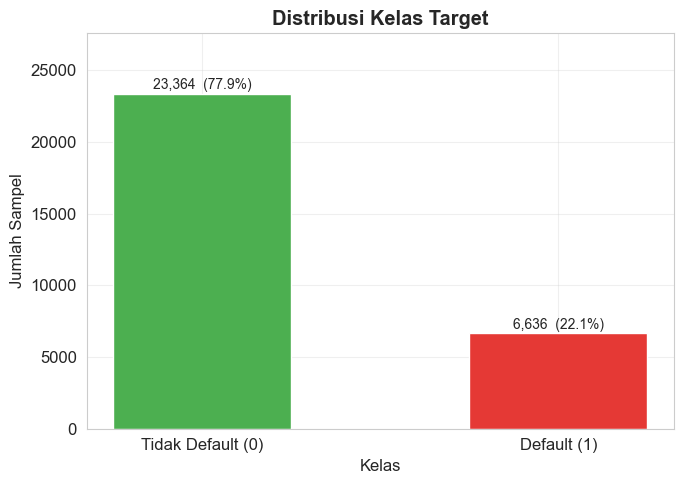

In [32]:
fig, ax = plt.subplots(figsize=(7, 5))

vc     = df['default'].value_counts()
labels = ['Tidak Default (0)', 'Default (1)']
colors = ['#4CAF50', '#E53935']
bars   = ax.bar(labels, [vc[0], vc[1]], color=colors, width=0.5, edgecolor='white')

for bar, val in zip(bars, [vc[0], vc[1]]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 100,
            f'{val:,}  ({val/len(df)*100:.1f}%)',
            ha='center', va='bottom', fontsize=10)

ax.set_title('Distribusi Kelas Target', fontweight='bold')
ax.set_ylabel('Jumlah Sampel')
ax.set_ylim(0, vc[0] * 1.18)
ax.set_xlabel('Kelas')
plt.tight_layout()
plt.show()

### 3.2 Distribusi Fitur Demografis

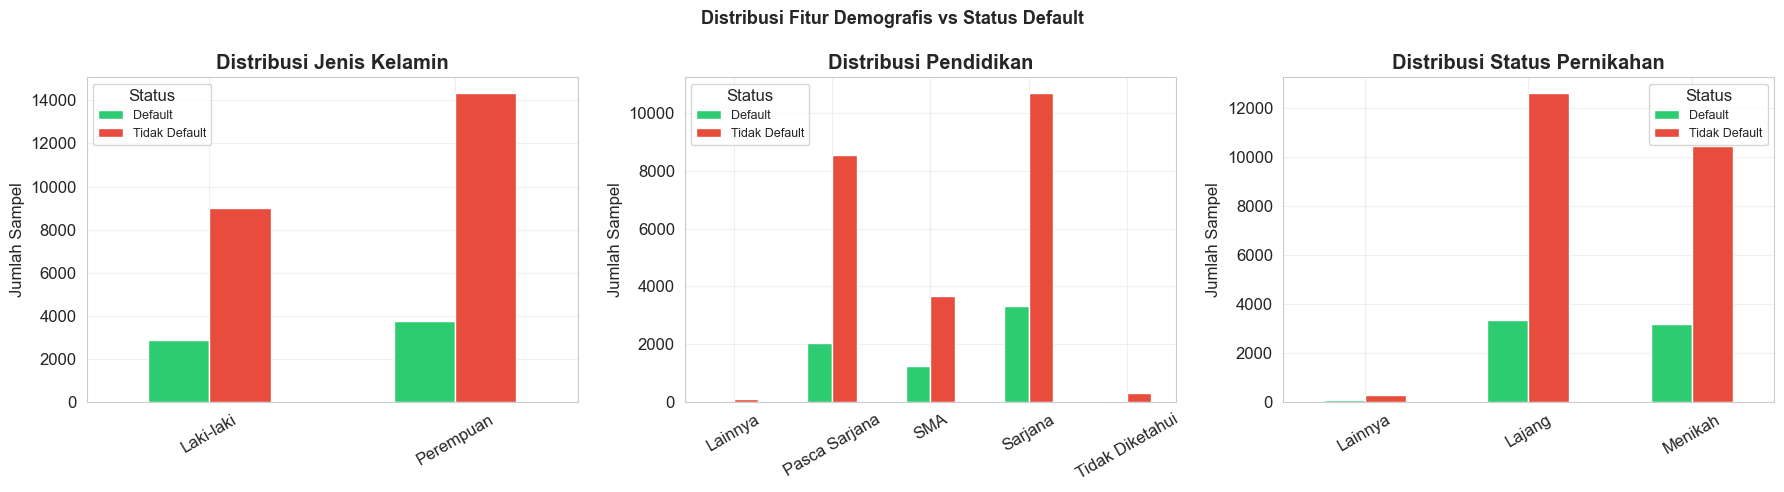

In [33]:
# Mapping nilai kategorik untuk keterbacaan
sex_map       = {1: 'Laki-laki', 2: 'Perempuan'}
edu_map       = {1: 'Pasca Sarjana', 2: 'Sarjana', 3: 'SMA', 4: 'Lainnya',
                 5: 'Tidak Diketahui', 6: 'Tidak Diketahui', 0: 'Tidak Diketahui'}
mar_map       = {0: 'Lainnya', 1: 'Menikah', 2: 'Lajang', 3: 'Lainnya'}

df_eda = df.copy()
df_eda['SEX_label']       = df_eda['SEX'].map(sex_map)
df_eda['EDUCATION_label'] = df_eda['EDUCATION'].map(edu_map).fillna('Lainnya')
df_eda['MARRIAGE_label']  = df_eda['MARRIAGE'].map(mar_map).fillna('Lainnya')
df_eda['default_label']   = df_eda['default'].map({0: 'Tidak Default', 1: 'Default'})

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (col, title) in zip(axes, [
    ('SEX_label',       'Distribusi Jenis Kelamin'),
    ('EDUCATION_label', 'Distribusi Pendidikan'),
    ('MARRIAGE_label',  'Distribusi Status Pernikahan'),
]):
    ct   = pd.crosstab(df_eda[col], df_eda['default_label'])
    ct.plot(kind='bar', ax=ax, color=['#2ecc71', '#e74c3c'],
            edgecolor='white', rot=30)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Jumlah Sampel')
    ax.legend(title='Status', fontsize=9)

plt.suptitle('Distribusi Fitur Demografis vs Status Default',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 3.3 Distribusi Fitur Numerik Kontinu

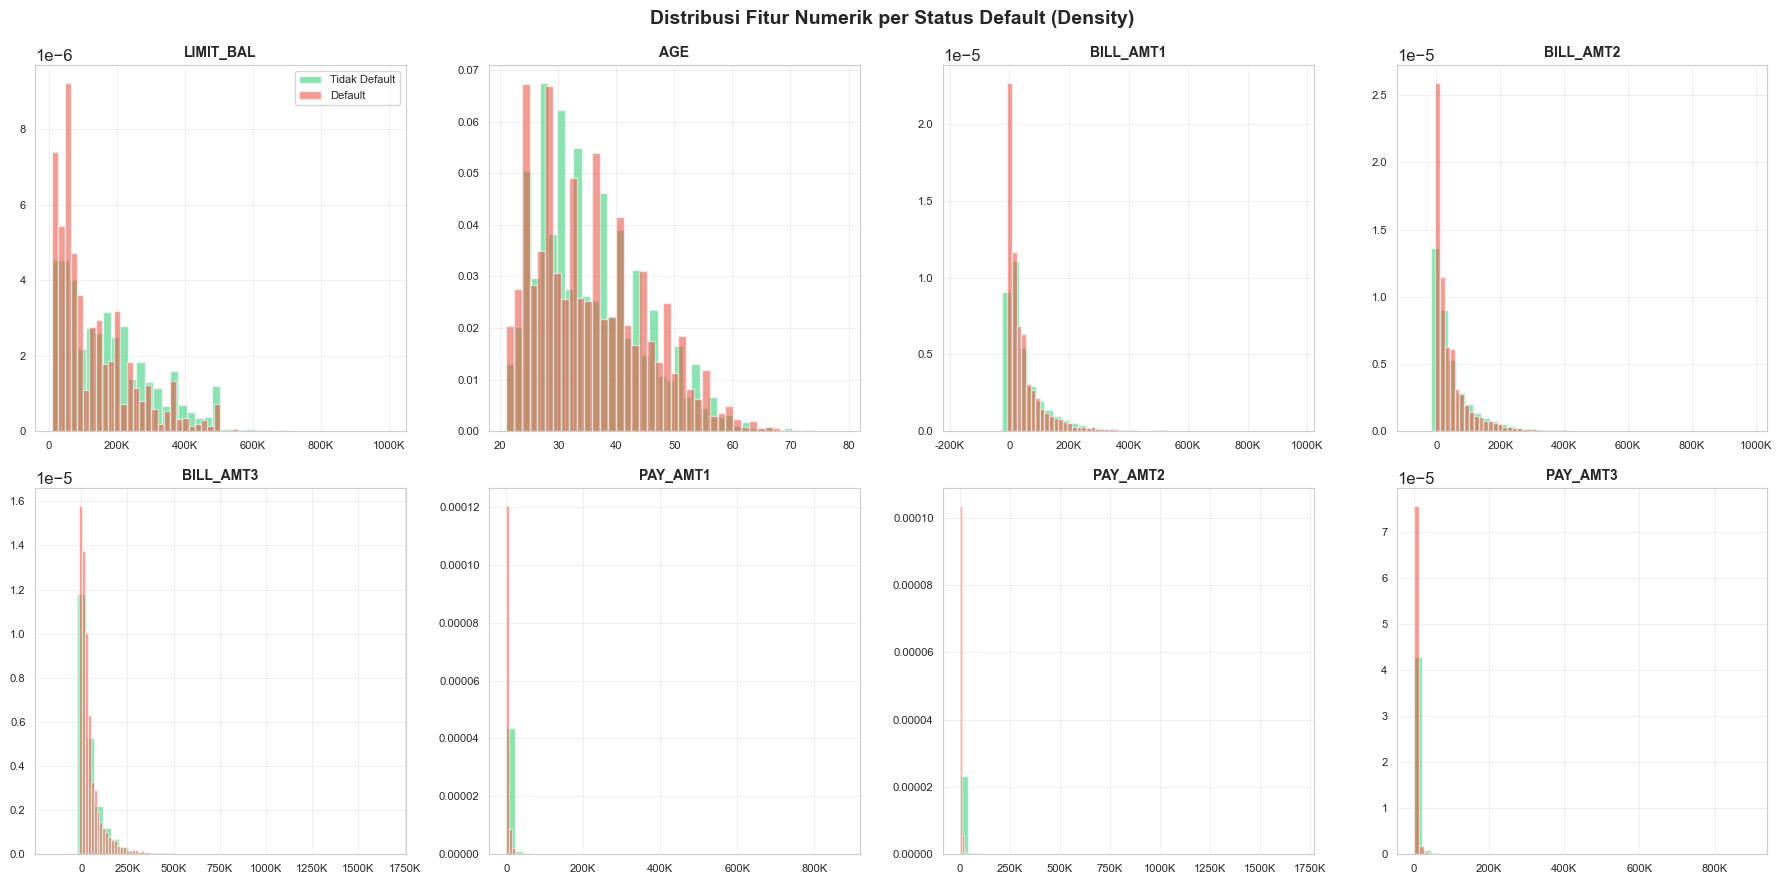

In [34]:
num_feats = ['LIMIT_BAL', 'AGE',
             'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3',
             'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3']

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes      = axes.ravel()

for i, col in enumerate(num_feats):
    for val, color, label in [(0, '#2ecc71', 'Tidak Default'), (1, '#e74c3c', 'Default')]:
        subset = df[df['default'] == val][col]
        axes[i].hist(subset, bins=40, alpha=0.55, color=color,
                     label=label, density=True)
    axes[i].set_title(col, fontweight='bold', fontsize=10)
    axes[i].tick_params(labelsize=8)
    axes[i].xaxis.set_major_formatter(mticker.FuncFormatter(
        lambda x, _: f'{x/1e3:.0f}K' if abs(x) >= 1000 else f'{x:.0f}'
    ))

axes[0].legend(fontsize=8)
plt.suptitle('Distribusi Fitur Numerik per Status Default (Density)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 3.4 Default Rate per Riwayat Pembayaran (PAY_0 – PAY_6)

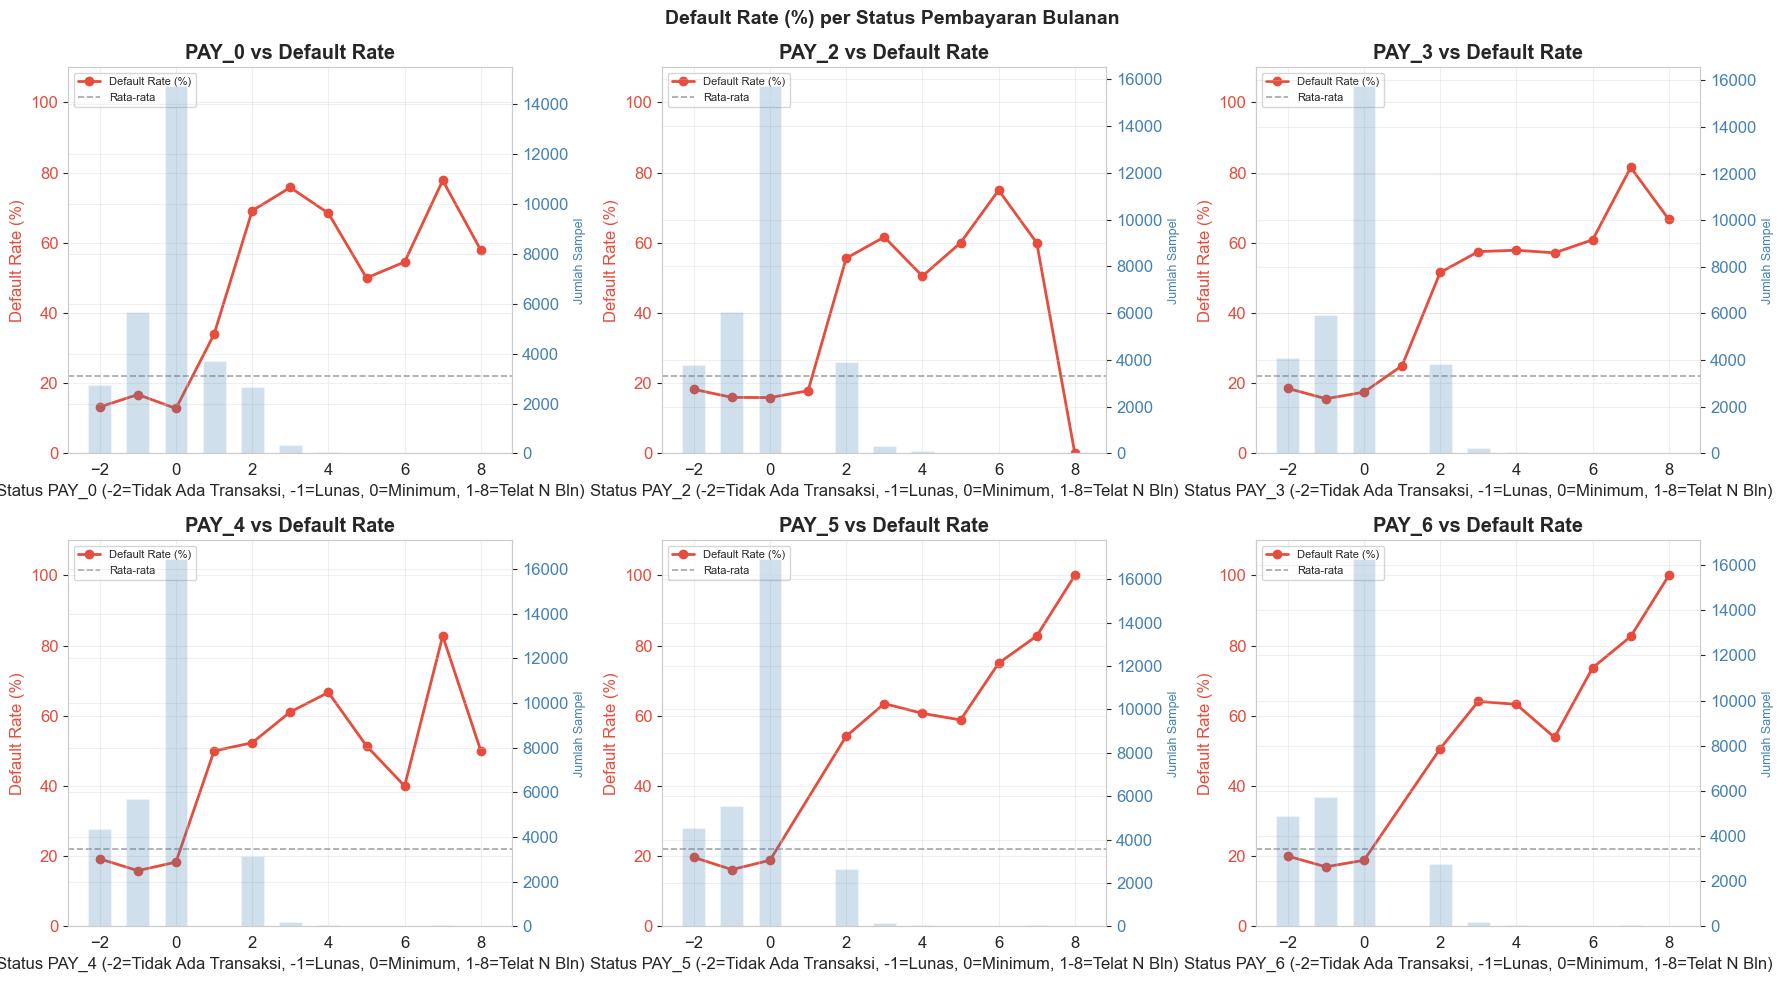

In [35]:
pay_cols = ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes      = axes.ravel()

for i, col in enumerate(pay_cols):
    dr = df.groupby(col)['default'].mean().reset_index()
    dr.columns = [col, 'default_rate']
    count = df[col].value_counts().sort_index()

    ax2 = axes[i].twinx()
    ax2.bar(count.index, count.values, color='steelblue', alpha=0.25,
            width=0.6, label='Jumlah Sampel')
    ax2.set_ylabel('Jumlah Sampel', color='steelblue', fontsize=9)
    ax2.tick_params(axis='y', labelcolor='steelblue')

    axes[i].plot(dr[col], dr['default_rate'] * 100, 'o-',
                 color='#e74c3c', lw=2, ms=6, label='Default Rate (%)')
    axes[i].axhline(df['default'].mean() * 100, color='gray',
                    ls='--', lw=1.2, alpha=0.7, label='Rata-rata')
    axes[i].set_title(f'{col} vs Default Rate', fontweight='bold')
    axes[i].set_xlabel(f'Status {col} (-2=Tidak Ada Transaksi, -1=Lunas, 0=Minimum, 1-8=Telat N Bln)')
    axes[i].set_ylabel('Default Rate (%)', color='#e74c3c')
    axes[i].tick_params(axis='y', labelcolor='#e74c3c')
    axes[i].set_ylim(0, 110)
    axes[i].legend(fontsize=8, loc='upper left')

plt.suptitle('Default Rate (%) per Status Pembayaran Bulanan',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 3.5 Heatmap Korelasi

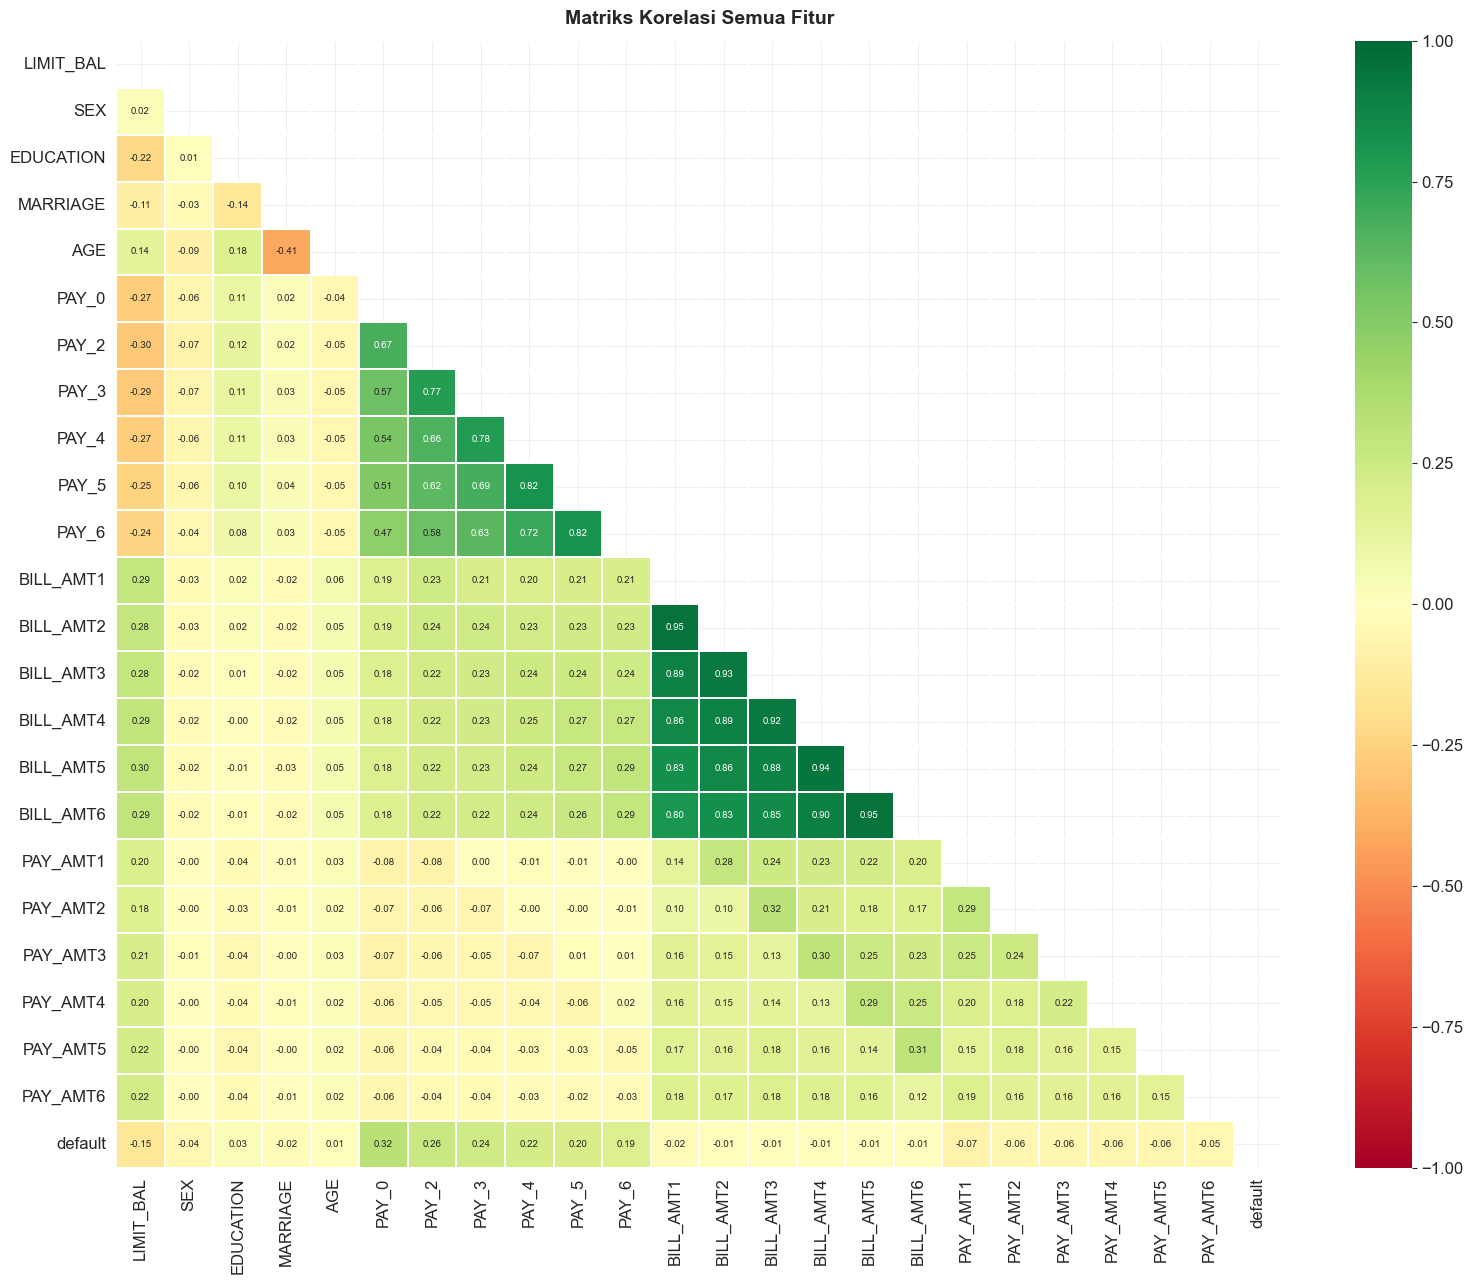

Top 10 fitur dengan korelasi tertinggi terhadap target:
  PAY_0          : r = +0.3248  (positif)
  PAY_2          : r = +0.2636  (positif)
  PAY_3          : r = +0.2353  (positif)
  PAY_4          : r = +0.2166  (positif)
  PAY_5          : r = +0.2041  (positif)
  PAY_6          : r = +0.1869  (positif)
  LIMIT_BAL      : r = -0.1535  (negatif)
  PAY_AMT1       : r = -0.0729  (negatif)
  PAY_AMT2       : r = -0.0586  (negatif)
  PAY_AMT4       : r = -0.0568  (negatif)


In [36]:
feature_cols = [c for c in df.columns if c != 'default']
corr = df[feature_cols + ['default']].corr()

fig, ax = plt.subplots(figsize=(16, 13))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=0.3, annot_kws={'size': 7},
            vmin=-1, vmax=1, ax=ax)
ax.set_title('Matriks Korelasi Semua Fitur', fontsize=14, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

# Korelasi terhadap target
corr_target = corr['default'].drop('default').sort_values(key=abs, ascending=False)
print('Top 10 fitur dengan korelasi tertinggi terhadap target:')
for feat, val in corr_target.head(10).items():
    direction = 'positif' if val > 0 else 'negatif'
    print(f'  {feat:<15}: r = {val:+.4f}  ({direction})')

### 3.6 Boxplot Limit Kredit dan Usia per Status Default

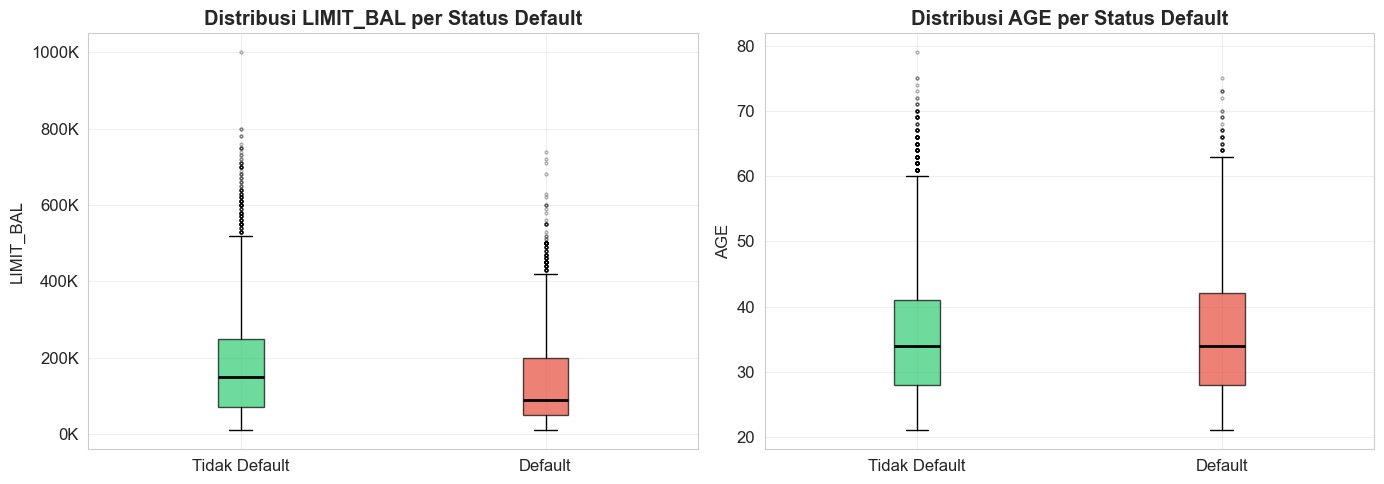

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col in zip(axes, ['LIMIT_BAL', 'AGE']):
    groups   = [df[df['default'] == 0][col], df[df['default'] == 1][col]]
    bp       = ax.boxplot(groups, patch_artist=True,
                          labels=['Tidak Default', 'Default'],
                          medianprops={'color': 'black', 'linewidth': 2},
                          flierprops={'markersize': 2, 'alpha': 0.3})
    for patch, c in zip(bp['boxes'], ['#2ecc71', '#e74c3c']):
        patch.set_facecolor(c)
        patch.set_alpha(0.7)
    ax.set_title(f'Distribusi {col} per Status Default', fontweight='bold')
    ax.set_ylabel(col)
    if col == 'LIMIT_BAL':
        ax.yaxis.set_major_formatter(
            mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K')
        )

plt.tight_layout()
plt.show()

---
## 4. Preprocessing

Pipeline preprocessing:
1. **Cleaning nilai tidak valid** pada kolom EDUCATION dan MARRIAGE (nilai 0, 5, 6 digabung ke kategori 'Lainnya').
2. **Feature engineering** — tambah fitur turunan yang relevan secara domain.
3. **Train/Test Split** — stratified 80/20 untuk menjaga proporsi kelas.
4. **StandardScaler** — hanya pada fitur numerik kontinu (tidak pada fitur ordinal PAY_*).

XGBoost secara teknis tidak memerlukan scaling, namun scaling diterapkan agar
perbandingan dengan model baseline (Logistic Regression) menjadi adil.

In [38]:
df_clean = df.copy()

# ── 4.1 Cleaning nilai tidak valid ──────────────────────────────────────────
# EDUCATION: 0, 5, 6 tidak terdefinisi dalam kode asli -> gabung ke 4 (Lainnya)
df_clean['EDUCATION'] = df_clean['EDUCATION'].replace({0: 4, 5: 4, 6: 4})
# MARRIAGE: 0 tidak terdefinisi -> gabung ke 3 (Lainnya)
df_clean['MARRIAGE']  = df_clean['MARRIAGE'].replace({0: 3})

edu_before = df['EDUCATION'].value_counts().sort_index()
edu_after  = df_clean['EDUCATION'].value_counts().sort_index()
print('Nilai EDUCATION sebelum cleaning:', dict(edu_before))
print('Nilai EDUCATION setelah cleaning:', dict(edu_after))

# ── 4.2 Feature Engineering ────────────────────────────────────────────────
# Rata-rata status keterlambatan pembayaran (semakin tinggi = semakin sering telat)
pay_status_cols = ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']
df_clean['PAY_AVG']         = df_clean[pay_status_cols].mean(axis=1)
df_clean['PAY_MAX']         = df_clean[pay_status_cols].max(axis=1)
df_clean['LATE_COUNT']      = (df_clean[pay_status_cols] > 0).sum(axis=1)

# Total tagihan dan total pembayaran
bill_cols  = ['BILL_AMT1','BILL_AMT2','BILL_AMT3','BILL_AMT4','BILL_AMT5','BILL_AMT6']
pay_cols_a = ['PAY_AMT1','PAY_AMT2','PAY_AMT3','PAY_AMT4','PAY_AMT5','PAY_AMT6']
df_clean['TOTAL_BILL']      = df_clean[bill_cols].sum(axis=1)
df_clean['TOTAL_PAY']       = df_clean[pay_cols_a].sum(axis=1)

# Rasio pembayaran terhadap tagihan (semakin mendekati 1 = semakin baik)
df_clean['PAY_BILL_RATIO']  = np.where(
    df_clean['TOTAL_BILL'] > 0,
    df_clean['TOTAL_PAY'] / df_clean['TOTAL_BILL'],
    0
).clip(0, 5)  # cap outlier ekstrem

# Utilisasi kredit (tagihan terbaru / limit)
df_clean['UTIL_RATE']       = np.where(
    df_clean['LIMIT_BAL'] > 0,
    df_clean['BILL_AMT1'] / df_clean['LIMIT_BAL'],
    0
).clip(0, 5)

print(f'\nFitur setelah feature engineering: {df_clean.shape[1] - 1} fitur')
print('Fitur baru yang ditambahkan:')
new_feats = ['PAY_AVG', 'PAY_MAX', 'LATE_COUNT', 'TOTAL_BILL',
             'TOTAL_PAY', 'PAY_BILL_RATIO', 'UTIL_RATE']
for f in new_feats:
    print(f'  {f:<18}: mean={df_clean[f].mean():.4f}, std={df_clean[f].std():.4f}')

Nilai EDUCATION sebelum cleaning: {0: np.int64(14), 1: np.int64(10585), 2: np.int64(14030), 3: np.int64(4917), 4: np.int64(123), 5: np.int64(280), 6: np.int64(51)}
Nilai EDUCATION setelah cleaning: {1: np.int64(10585), 2: np.int64(14030), 3: np.int64(4917), 4: np.int64(468)}

Fitur setelah feature engineering: 30 fitur
Fitur baru yang ditambahkan:
  PAY_AVG           : mean=-0.1824, std=0.9822
  PAY_MAX           : mean=0.4387, std=1.3452
  LATE_COUNT        : mean=0.8342, std=1.5543
  TOTAL_BILL        : mean=269861.6712, std=379564.3312
  TOTAL_PAY         : mean=31651.3926, std=60827.6779
  PAY_BILL_RATIO    : mean=0.3704, std=0.5907
  UTIL_RATE         : mean=0.4239, std=0.4105


In [39]:
# ── 4.3 Train/Test Split ───────────────────────────────────────────────────
feature_cols = [c for c in df_clean.columns if c != 'default']
X = df_clean[feature_cols].copy()
y = df_clean['default'].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

# ── 4.4 Standard Scaler (untuk baseline Logistic Regression) ──────────────
# Fitur yang perlu di-scale (numerik kontinu)
scale_cols = ['LIMIT_BAL', 'AGE',
              'BILL_AMT1','BILL_AMT2','BILL_AMT3','BILL_AMT4','BILL_AMT5','BILL_AMT6',
              'PAY_AMT1','PAY_AMT2','PAY_AMT3','PAY_AMT4','PAY_AMT5','PAY_AMT6',
              'TOTAL_BILL','TOTAL_PAY','PAY_BILL_RATIO','UTIL_RATE']

scaler      = StandardScaler()
X_train_sc  = X_train.copy()
X_test_sc   = X_test.copy()
X_train_sc[scale_cols] = scaler.fit_transform(X_train[scale_cols])
X_test_sc[scale_cols]  = scaler.transform(X_test[scale_cols])

# Scale_pos_weight untuk XGBoost: jumlah sampel negatif / jumlah sampel positif
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
spw       = neg_count / pos_count

print('=== Ringkasan Preprocessing ===')
print(f'Total sampel              : {len(X):,}')
print(f'Train set                 : {len(X_train):,} ({len(X_train)/len(X)*100:.0f}%)')
print(f'Test set                  : {len(X_test):,} ({len(X_test)/len(X)*100:.0f}%)')
print(f'Fitur                     : {X.shape[1]}')
print(f'Proporsi positif (train)  : {pos_count:,} ({pos_count/len(y_train)*100:.1f}%)')
print(f'Proporsi negatif (train)  : {neg_count:,} ({neg_count/len(y_train)*100:.1f}%)')
print(f'scale_pos_weight          : {spw:.2f}')
print(f'Missing values (train)    : {X_train.isnull().sum().sum()}')

=== Ringkasan Preprocessing ===
Total sampel              : 30,000
Train set                 : 24,000 (80%)
Test set                  : 6,000 (20%)
Fitur                     : 30
Proporsi positif (train)  : 5,309 (22.1%)
Proporsi negatif (train)  : 18,691 (77.9%)
scale_pos_weight          : 3.52
Missing values (train)    : 0


---
## 5. Training Model XGBoost

Tiga tahap pelatihan:

| Tahap | Metode | Tujuan |
|---|---|---|
| **5.1** | XGBoost Default | Baseline tanpa tuning |
| **5.2** | XGBoost + scale_pos_weight | Atasi class imbalance |
| **5.3** | XGBoost Tuned (manual grid) | Konfigurasi optimal dari eksperimen |

Hyperparameter yang di-tuning:
- `n_estimators`: Jumlah pohon (100, 200, 300)
- `max_depth`: Kedalaman pohon (3, 5, 7)
- `learning_rate`: Laju pembelajaran (0.05, 0.1, 0.2)
- `subsample`: Fraksi sampel per pohon (0.8, 1.0)
- `colsample_bytree`: Fraksi fitur per pohon (0.8, 1.0)

In [40]:
# ── 5.1 XGBoost Default ───────────────────────────────────────────────────
print('TAHAP 5.1: XGBoost Default (tanpa tuning)')
print('=' * 55)

xgb_default = XGBClassifier(
    random_state     = RANDOM_STATE,
    eval_metric      = 'logloss',
    use_label_encoder= False,
    verbosity        = 0
)
xgb_default.fit(X_train, y_train)
y_pred_default   = xgb_default.predict(X_test)
y_prob_default   = xgb_default.predict_proba(X_test)[:, 1]

print(f'  Accuracy  : {accuracy_score(y_test, y_pred_default):.4f}')
print(f'  F1-Score  : {f1_score(y_test, y_pred_default):.4f}')
print(f'  ROC-AUC   : {roc_auc_score(y_test, y_prob_default):.4f}')
print(f'  Recall    : {recall_score(y_test, y_pred_default):.4f}')
print(f'  Precision : {precision_score(y_test, y_pred_default):.4f}')

TAHAP 5.1: XGBoost Default (tanpa tuning)
  Accuracy  : 0.8110
  F1-Score  : 0.4615
  ROC-AUC   : 0.7614
  Recall    : 0.3662
  Precision : 0.6239


In [41]:
# ── 5.2 XGBoost + scale_pos_weight ────────────────────────────────────────
print('TAHAP 5.2: XGBoost + scale_pos_weight')
print('=' * 55)

xgb_balanced = XGBClassifier(
    scale_pos_weight = spw,
    random_state     = RANDOM_STATE,
    eval_metric      = 'logloss',
    use_label_encoder= False,
    verbosity        = 0
)
xgb_balanced.fit(X_train, y_train)
y_pred_balanced = xgb_balanced.predict(X_test)
y_prob_balanced = xgb_balanced.predict_proba(X_test)[:, 1]

print(f'  scale_pos_weight = {spw:.2f}')
print(f'  Accuracy         : {accuracy_score(y_test, y_pred_balanced):.4f}')
print(f'  F1-Score         : {f1_score(y_test, y_pred_balanced):.4f}')
print(f'  ROC-AUC          : {roc_auc_score(y_test, y_prob_balanced):.4f}')
print(f'  Recall           : {recall_score(y_test, y_pred_balanced):.4f}')
print(f'  Precision        : {precision_score(y_test, y_pred_balanced):.4f}')

TAHAP 5.2: XGBoost + scale_pos_weight
  scale_pos_weight = 3.52
  Accuracy         : 0.7592
  F1-Score         : 0.5204
  ROC-AUC          : 0.7604
  Recall           : 0.5908
  Precision        : 0.4650


In [42]:
# ── 5.3 Grid Search Manual ────────────────────────────────────────────────
from itertools import product as iproduct

print('TAHAP 5.3: Grid Search Hyperparameter XGBoost')
print('Metrik utama: F1-Score (cross-validation, n_splits=3)')
print('=' * 80)

param_grid = {
    'n_estimators' : [100, 200],
    'max_depth'    : [3, 5, 7],
    'learning_rate': [0.05, 0.1, 0.2],
    'subsample'    : [0.8, 1.0],
}

cv      = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
results = []

print(f'  {"n_est":>6} | {"depth":>5} | {"lr":>5} | {"sub":>4} | {"CV F1":>8} | {"CV AUC":>8}')
print('  ' + '-' * 55)

for n_est, depth, lr, sub in iproduct(
    param_grid['n_estimators'],
    param_grid['max_depth'],
    param_grid['learning_rate'],
    param_grid['subsample']
):
    model = XGBClassifier(
        n_estimators      = n_est,
        max_depth         = depth,
        learning_rate     = lr,
        subsample         = sub,
        colsample_bytree  = 0.8,
        scale_pos_weight  = spw,
        random_state      = RANDOM_STATE,
        eval_metric       = 'logloss',
        use_label_encoder = False,
        verbosity         = 0
    )
    cv_f1  = cross_val_score(model, X_train, y_train, cv=cv,
                             scoring='f1',      n_jobs=-1).mean()
    cv_auc = cross_val_score(model, X_train, y_train, cv=cv,
                             scoring='roc_auc', n_jobs=-1).mean()
    results.append(dict(
        n_estimators=n_est, max_depth=depth, learning_rate=lr,
        subsample=sub, cv_f1=cv_f1, cv_auc=cv_auc
    ))
    print(f'  {n_est:>6} | {depth:>5} | {lr:>5.2f} | {sub:>4.1f} | {cv_f1:>8.4f} | {cv_auc:>8.4f}')

df_grid = pd.DataFrame(results)
best_i  = df_grid['cv_f1'].idxmax()
best_p  = df_grid.loc[best_i]

print()
print(f'  -> Konfigurasi terbaik (CV F1 = {best_p["cv_f1"]:.4f}):')
print(f'     n_estimators  = {int(best_p["n_estimators"])}')
print(f'     max_depth     = {int(best_p["max_depth"])}')
print(f'     learning_rate = {best_p["learning_rate"]}')
print(f'     subsample     = {best_p["subsample"]}')

TAHAP 5.3: Grid Search Hyperparameter XGBoost
Metrik utama: F1-Score (cross-validation, n_splits=3)
   n_est | depth |    lr |  sub |    CV F1 |   CV AUC
  -------------------------------------------------------
     100 |     3 |  0.05 |  0.8 |   0.5383 |   0.7853
     100 |     3 |  0.05 |  1.0 |   0.5362 |   0.7847
     100 |     3 |  0.10 |  0.8 |   0.5402 |   0.7856
     100 |     3 |  0.10 |  1.0 |   0.5375 |   0.7852
     100 |     3 |  0.20 |  0.8 |   0.5381 |   0.7822
     100 |     3 |  0.20 |  1.0 |   0.5366 |   0.7829
     100 |     5 |  0.05 |  0.8 |   0.5422 |   0.7860
     100 |     5 |  0.05 |  1.0 |   0.5407 |   0.7846
     100 |     5 |  0.10 |  0.8 |   0.5399 |   0.7822
     100 |     5 |  0.10 |  1.0 |   0.5374 |   0.7812
     100 |     5 |  0.20 |  0.8 |   0.5255 |   0.7712
     100 |     5 |  0.20 |  1.0 |   0.5243 |   0.7714
     100 |     7 |  0.05 |  0.8 |   0.5408 |   0.7821
     100 |     7 |  0.05 |  1.0 |   0.5382 |   0.7802
     100 |     7 |  0.10 |  0.8 

---
## 6. Training Model Final XGBoost

  RINGKASAN MODEL XGBoost FINAL
  n_estimators     : 100
  max_depth        : 5
  learning_rate    : 0.05
  subsample        : 0.8
  colsample_bytree : 0.8
  scale_pos_weight : 3.52
  reg_alpha        : 0.1
  reg_lambda       : 1.0
  min_child_weight : 5


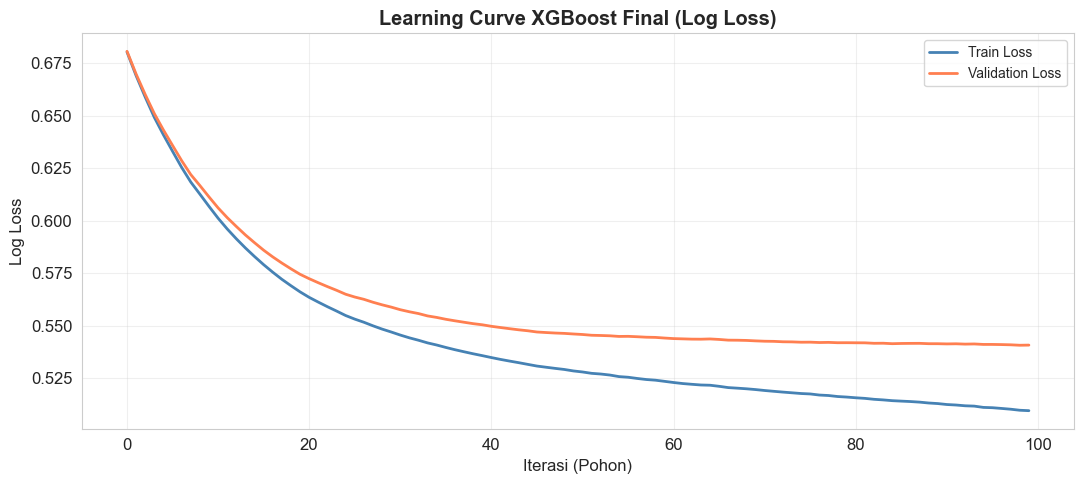

In [43]:
# Latih model final dengan konfigurasi terbaik dari grid search
xgb_final = XGBClassifier(
    n_estimators      = int(best_p['n_estimators']),
    max_depth         = int(best_p['max_depth']),
    learning_rate     = best_p['learning_rate'],
    subsample         = best_p['subsample'],
    colsample_bytree  = 0.8,
    scale_pos_weight  = spw,
    reg_alpha         = 0.1,
    reg_lambda        = 1.0,
    min_child_weight  = 5,
    random_state      = RANDOM_STATE,
    eval_metric       = 'logloss',
    use_label_encoder = False,
    verbosity         = 0
)

xgb_final.fit(
    X_train, y_train,
    eval_set       = [(X_train, y_train), (X_test, y_test)],
    verbose        = False
)

y_pred_final = xgb_final.predict(X_test)
y_prob_final = xgb_final.predict_proba(X_test)[:, 1]

print('=' * 65)
print('  RINGKASAN MODEL XGBoost FINAL')
print('=' * 65)
print(f'  n_estimators     : {xgb_final.n_estimators}')
print(f'  max_depth        : {xgb_final.max_depth}')
print(f'  learning_rate    : {xgb_final.learning_rate}')
print(f'  subsample        : {xgb_final.subsample}')
print(f'  colsample_bytree : {xgb_final.colsample_bytree}')
print(f'  scale_pos_weight : {xgb_final.scale_pos_weight:.2f}')
print(f'  reg_alpha        : {xgb_final.reg_alpha}')
print(f'  reg_lambda       : {xgb_final.reg_lambda}')
print(f'  min_child_weight : {xgb_final.min_child_weight}')

# Plot learning curve
evals_result = xgb_final.evals_result()
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(evals_result['validation_0']['logloss'], label='Train Loss', color='steelblue', lw=2)
ax.plot(evals_result['validation_1']['logloss'], label='Validation Loss', color='coral', lw=2)
ax.set_title('Learning Curve XGBoost Final (Log Loss)', fontweight='bold')
ax.set_xlabel('Iterasi (Pohon)')
ax.set_ylabel('Log Loss')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

---
## 7. Evaluasi Model

### 7.1 Metrik Evaluasi XGBoost Final

In [44]:
acc  = accuracy_score(y_test, y_pred_final)
prec = precision_score(y_test, y_pred_final)
rec  = recall_score(y_test, y_pred_final)
f1   = f1_score(y_test, y_pred_final)
auc  = roc_auc_score(y_test, y_prob_final)
ap   = average_precision_score(y_test, y_prob_final)

print('=' * 65)
print('  EVALUASI METRIK — XGBoost Final (Test Set)')
print('=' * 65)
print(f'  Accuracy          : {acc:.4f}')
print(f'  Precision         : {prec:.4f}  (dari semua prediksi default, berapa % benar)')
print(f'  Recall            : {rec:.4f}  (dari semua default asli, berapa % terdeteksi)')
print(f'  F1-Score          : {f1:.4f}  (harmonic mean Precision & Recall)')
print(f'  ROC-AUC           : {auc:.4f}')
print(f'  Avg Precision     : {ap:.4f}  (area di bawah kurva Precision-Recall)')
print('=' * 65)
print()
print('Classification Report:')
print(classification_report(y_test, y_pred_final,
                             target_names=['Tidak Default', 'Default']))

  EVALUASI METRIK — XGBoost Final (Test Set)
  Accuracy          : 0.7602
  Precision         : 0.4686  (dari semua prediksi default, berapa % benar)
  Recall            : 0.6292  (dari semua default asli, berapa % terdeteksi)
  F1-Score          : 0.5372  (harmonic mean Precision & Recall)
  ROC-AUC           : 0.7829
  Avg Precision     : 0.5602  (area di bawah kurva Precision-Recall)

Classification Report:
               precision    recall  f1-score   support

Tidak Default       0.88      0.80      0.84      4673
      Default       0.47      0.63      0.54      1327

     accuracy                           0.76      6000
    macro avg       0.68      0.71      0.69      6000
 weighted avg       0.79      0.76      0.77      6000



### 7.2 Confusion Matrix

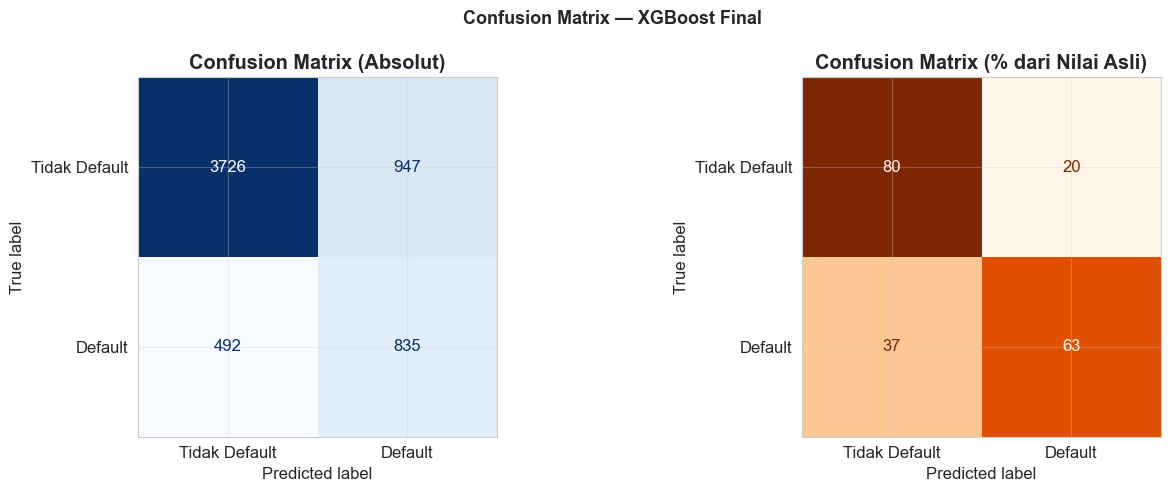

  True Positive   (TP):   835  (default terdeteksi benar)
  True Negative   (TN): 3,726  (tidak default terdeteksi benar)
  False Positive  (FP):   947  (tidak default, diprediksi default)
  False Negative  (FN):   492  (default, diprediksi tidak default — paling berbahaya)


In [45]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix (absolut)
cm   = confusion_matrix(y_test, y_pred_final)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Tidak Default', 'Default'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix (Absolut)', fontweight='bold')

# Confusion Matrix (persentase dari nilai asli)
cm_pct  = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
disp2   = ConfusionMatrixDisplay(confusion_matrix=cm_pct.round(1),
                                  display_labels=['Tidak Default', 'Default'])
disp2.plot(ax=axes[1], colorbar=False, cmap='Oranges')
axes[1].set_title('Confusion Matrix (% dari Nilai Asli)', fontweight='bold')

plt.suptitle('Confusion Matrix — XGBoost Final', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'  True Positive   (TP): {tp:5,}  (default terdeteksi benar)')
print(f'  True Negative   (TN): {tn:5,}  (tidak default terdeteksi benar)')
print(f'  False Positive  (FP): {fp:5,}  (tidak default, diprediksi default)')
print(f'  False Negative  (FN): {fn:5,}  (default, diprediksi tidak default — paling berbahaya)')

### 7.3 Kurva ROC dan Precision-Recall

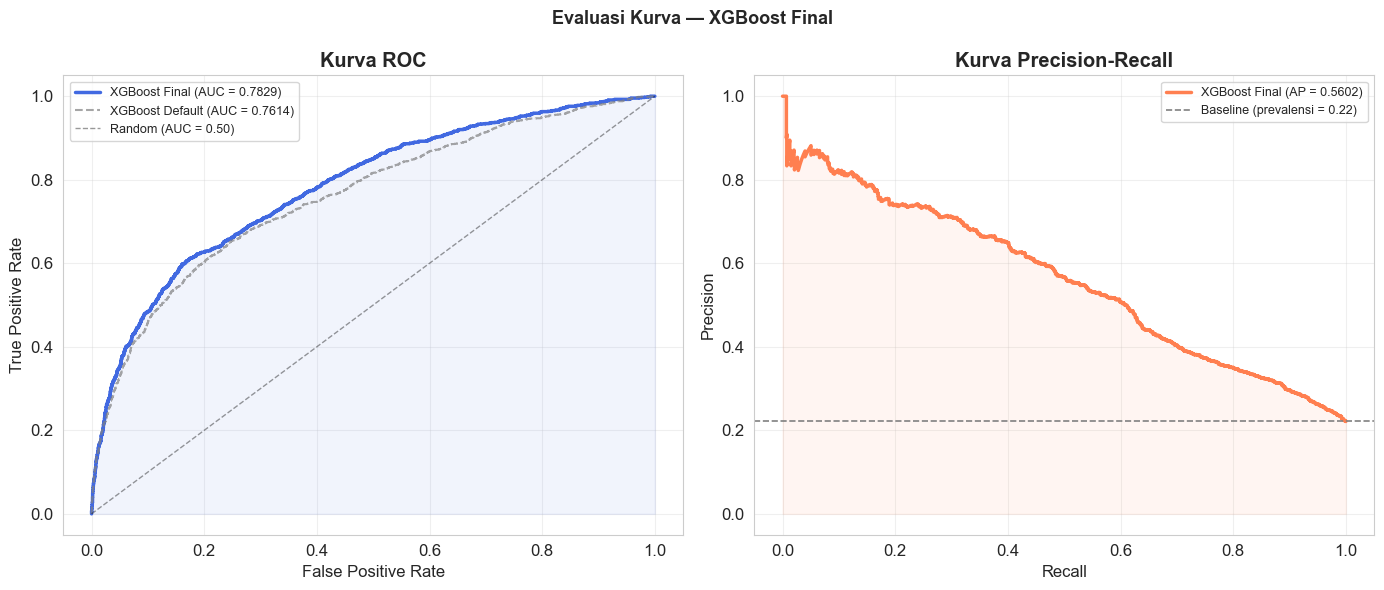

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ── Kurva ROC ─────────────────────────────────────────────────────────────
fpr, tpr, thr_roc = roc_curve(y_test, y_prob_final)
axes[0].plot(fpr, tpr, color='royalblue', lw=2.5,
             label=f'XGBoost Final (AUC = {auc:.4f})')

# Tambahkan kurva model lain sebagai referensi visual
fpr_d, tpr_d, _ = roc_curve(y_test, y_prob_default)
auc_d = roc_auc_score(y_test, y_prob_default)
axes[0].plot(fpr_d, tpr_d, color='gray', lw=1.5, ls='--',
             label=f'XGBoost Default (AUC = {auc_d:.4f})', alpha=0.7)

axes[0].plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.4, label='Random (AUC = 0.50)')
axes[0].fill_between(fpr, tpr, alpha=0.07, color='royalblue')
axes[0].set_title('Kurva ROC', fontweight='bold')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend(fontsize=9)

# ── Kurva Precision-Recall ────────────────────────────────────────────────
prec_curve, rec_curve, thr_pr = precision_recall_curve(y_test, y_prob_final)
axes[1].plot(rec_curve, prec_curve, color='coral', lw=2.5,
             label=f'XGBoost Final (AP = {ap:.4f})')
baseline_pr = y_test.mean()
axes[1].axhline(baseline_pr, color='gray', ls='--', lw=1.2,
                label=f'Baseline (prevalensi = {baseline_pr:.2f})')
axes[1].fill_between(rec_curve, prec_curve, alpha=0.07, color='coral')
axes[1].set_title('Kurva Precision-Recall', fontweight='bold')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].legend(fontsize=9)

plt.suptitle('Evaluasi Kurva — XGBoost Final', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 7.4 Analisis Threshold Optimal

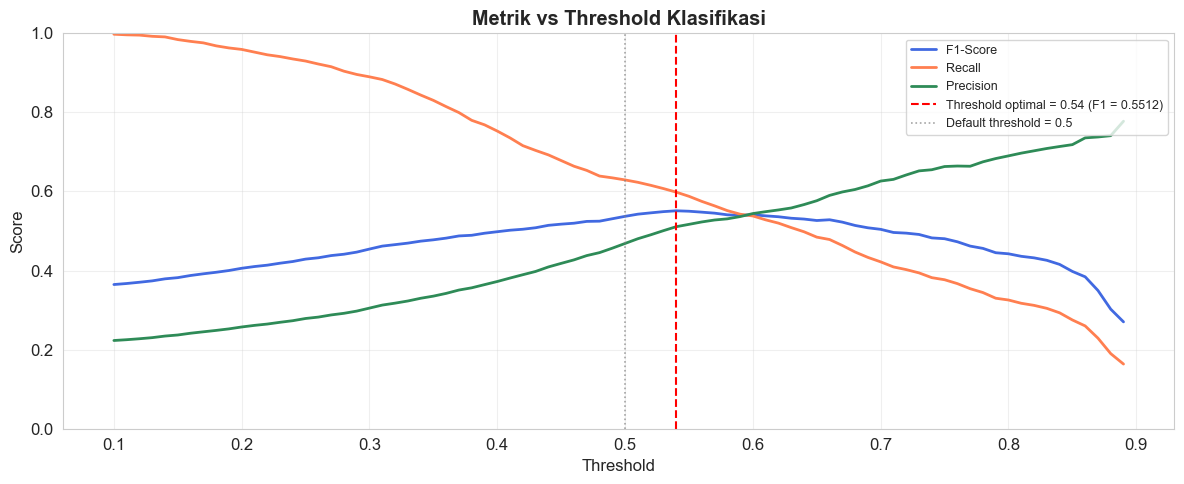

Threshold default (0.5)  -> F1=0.5372, Recall=0.6292, Prec=0.4686
Threshold optimal (0.54) -> F1=0.5512, Recall=0.5983, Prec=0.5109


In [47]:
# Cari threshold yang memaksimalkan F1-Score
thresholds = np.arange(0.1, 0.9, 0.01)
f1_scores  = [f1_score(y_test, (y_prob_final >= t).astype(int)) for t in thresholds]
rec_scores = [recall_score(y_test, (y_prob_final >= t).astype(int)) for t in thresholds]
pre_scores = [precision_score(y_test, (y_prob_final >= t).astype(int),
                               zero_division=0) for t in thresholds]

best_thr_i  = np.argmax(f1_scores)
best_thr    = thresholds[best_thr_i]
best_f1_thr = f1_scores[best_thr_i]

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(thresholds, f1_scores,  label='F1-Score',  color='royalblue', lw=2)
ax.plot(thresholds, rec_scores, label='Recall',    color='coral',     lw=2)
ax.plot(thresholds, pre_scores, label='Precision', color='seagreen',  lw=2)
ax.axvline(best_thr, color='red', ls='--', lw=1.5,
           label=f'Threshold optimal = {best_thr:.2f} (F1 = {best_f1_thr:.4f})')
ax.axvline(0.5, color='gray', ls=':', lw=1.2, alpha=0.7, label='Default threshold = 0.5')
ax.set_title('Metrik vs Threshold Klasifikasi', fontweight='bold')
ax.set_xlabel('Threshold')
ax.set_ylabel('Score')
ax.set_ylim(0, 1)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

# Evaluasi dengan threshold optimal
y_pred_opt = (y_prob_final >= best_thr).astype(int)
print(f'Threshold default (0.5)  -> F1={f1:.4f}, Recall={rec:.4f}, Prec={prec:.4f}')
print(f'Threshold optimal ({best_thr:.2f}) -> F1={f1_score(y_test, y_pred_opt):.4f}, '
      f'Recall={recall_score(y_test, y_pred_opt):.4f}, '
      f'Prec={precision_score(y_test, y_pred_opt):.4f}')

---
## 8. Feature Importance

### 8.1 XGBoost Built-in Importance (Weight, Gain, Cover)

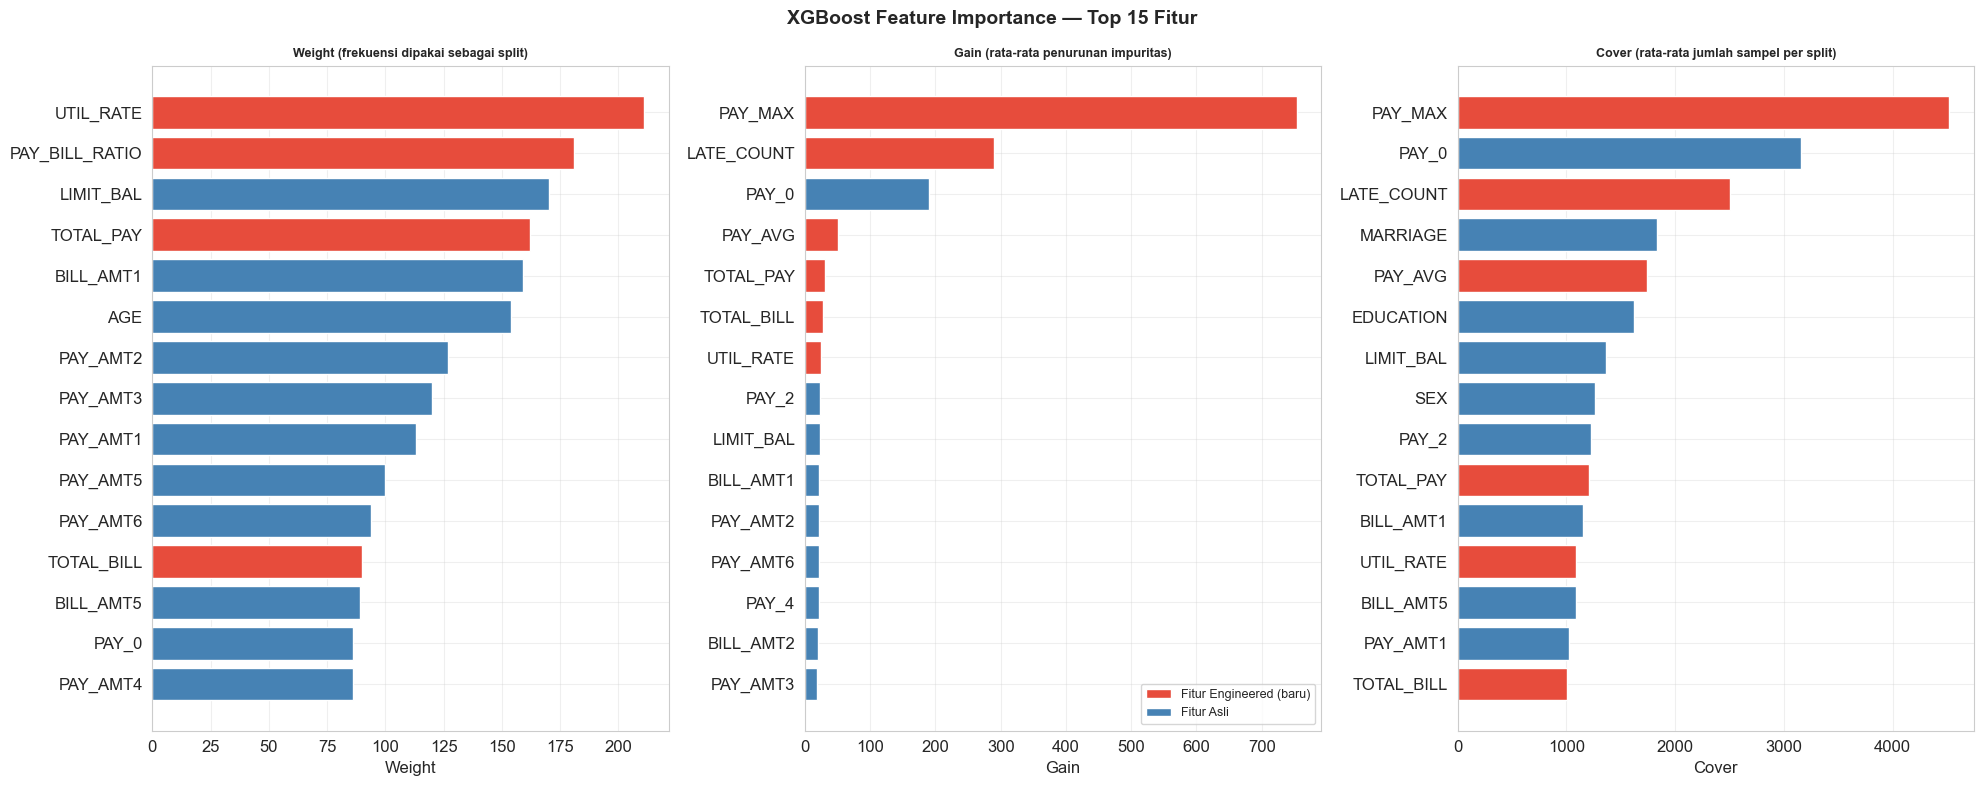

In [48]:
importance_types = ['weight', 'gain', 'cover']
imp_labels = {
    'weight': 'Weight (frekuensi dipakai sebagai split)',
    'gain'  : 'Gain (rata-rata penurunan impuritas)',
    'cover' : 'Cover (rata-rata jumlah sampel per split)'
}

fig, axes = plt.subplots(1, 3, figsize=(20, 8))

for ax, imp_type in zip(axes, importance_types):
    imp_dict  = xgb_final.get_booster().get_score(importance_type=imp_type)
    imp_df    = (pd.Series(imp_dict)
                   .sort_values(ascending=True)
                   .tail(15))
    colors_bar = ['#e74c3c' if f in new_feats else 'steelblue' for f in imp_df.index]
    ax.barh(imp_df.index, imp_df.values, color=colors_bar, edgecolor='white')
    ax.set_title(imp_labels[imp_type], fontweight='bold', fontsize=9)
    ax.set_xlabel(imp_type.capitalize())

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#e74c3c', label='Fitur Engineered (baru)'),
    Patch(facecolor='steelblue', label='Fitur Asli')
]
axes[1].legend(handles=legend_elements, fontsize=9, loc='lower right')

plt.suptitle('XGBoost Feature Importance — Top 15 Fitur',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 8.2 Feature Importance — Gain (Peringkat Lengkap)

In [49]:
gain_dict = xgb_final.get_booster().get_score(importance_type='gain')
gain_df   = (pd.Series(gain_dict)
               .reset_index()
               .rename(columns={'index': 'Feature', 0: 'Gain'})
               .sort_values('Gain', ascending=False))

# Normalisasi ke 0-100
gain_df['Gain_Norm'] = gain_df['Gain'] / gain_df['Gain'].sum() * 100
gain_df['Kumulatif'] = gain_df['Gain_Norm'].cumsum()
gain_df['Engineered'] = gain_df['Feature'].isin(new_feats)

print('Peringkat Feature Importance (Gain, ternormalisasi):')
print(f'{"Rank":>5} | {"Fitur":<18} | {"Gain (%)":>9} | {"Kumulatif":>10} | Tipe')
print('-' * 62)
for i, row in gain_df.iterrows():
    tipe = 'Engineered' if row['Engineered'] else 'Asli'
    rank = gain_df.index.get_loc(i) + 1
    print(f'{rank:>5} | {row["Feature"]:<18} | {row["Gain_Norm"]:>9.2f}% | {row["Kumulatif"]:>9.2f}% | {tipe}')

Peringkat Feature Importance (Gain, ternormalisasi):
 Rank | Fitur              |  Gain (%) |  Kumulatif | Tipe
--------------------------------------------------------------
    1 | PAY_MAX            |     42.83% |     42.83% | Engineered
    2 | LATE_COUNT         |     16.43% |     59.26% | Engineered
    3 | PAY_0              |     10.83% |     70.10% | Asli
    4 | PAY_AVG            |      2.84% |     72.93% | Engineered
    5 | TOTAL_PAY          |      1.78% |     74.71% | Engineered
    6 | TOTAL_BILL         |      1.53% |     76.24% | Engineered
    7 | UTIL_RATE          |      1.37% |     77.62% | Engineered
    8 | PAY_2              |      1.35% |     78.96% | Asli
    9 | LIMIT_BAL          |      1.32% |     80.28% | Asli
   10 | BILL_AMT1          |      1.25% |     81.53% | Asli
   11 | PAY_AMT2           |      1.23% |     82.76% | Asli
   12 | PAY_AMT6           |      1.20% |     83.96% | Asli
   13 | PAY_4              |      1.18% |     85.15% | Asli
   14 | B

---
## 9. Perbandingan Model

Perbandingan XGBoost Final dengan model baseline: Logistic Regression dan Random Forest.

In [50]:
# ── Logistic Regression ───────────────────────────────────────────────────
lr_model   = LogisticRegression(class_weight='balanced', max_iter=1000,
                                 random_state=RANDOM_STATE, C=0.1)
lr_model.fit(X_train_sc, y_train)
lr_pred    = lr_model.predict(X_test_sc)
lr_prob    = lr_model.predict_proba(X_test_sc)[:, 1]

# ── Random Forest ─────────────────────────────────────────────────────────
rf_model   = RandomForestClassifier(n_estimators=200, class_weight='balanced',
                                     random_state=RANDOM_STATE, n_jobs=-1)
rf_model.fit(X_train, y_train)
rf_pred    = rf_model.predict(X_test)
rf_prob    = rf_model.predict_proba(X_test)[:, 1]

# ── Tabel Perbandingan ────────────────────────────────────────────────────
def get_metrics(y_true, y_pred, y_prob):
    return {
        'Accuracy' : accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall'   : recall_score(y_true, y_pred),
        'F1-Score' : f1_score(y_true, y_pred),
        'ROC-AUC'  : roc_auc_score(y_true, y_prob),
        'Avg-Prec' : average_precision_score(y_true, y_prob),
    }

models = {
    'Logistic Regression' : get_metrics(y_test, lr_pred, lr_prob),
    'Random Forest'        : get_metrics(y_test, rf_pred, rf_prob),
    'XGBoost Default'      : get_metrics(y_test, y_pred_default, y_prob_default),
    'XGBoost + SPW'        : get_metrics(y_test, y_pred_balanced, y_prob_balanced),
    'XGBoost Final'        : get_metrics(y_test, y_pred_final, y_prob_final),
}

df_compare = pd.DataFrame(models).T

print('=' * 80)
print('  PERBANDINGAN MODEL')
print('=' * 80)
print(df_compare.round(4).to_string())
print()

for metric in ['F1-Score', 'ROC-AUC']:
    best_model = df_compare[metric].idxmax()
    best_val   = df_compare[metric].max()
    print(f'  {metric} terbaik: {best_model} ({best_val:.4f})')

  PERBANDINGAN MODEL
                     Accuracy  Precision  Recall  F1-Score  ROC-AUC  Avg-Prec
Logistic Regression    0.7425     0.4404  0.6066    0.5103   0.7445    0.5007
Random Forest          0.8128     0.6437  0.3444    0.4487   0.7615    0.5388
XGBoost Default        0.8110     0.6239  0.3662    0.4615   0.7614    0.5407
XGBoost + SPW          0.7592     0.4650  0.5908    0.5204   0.7604    0.5349
XGBoost Final          0.7602     0.4686  0.6292    0.5372   0.7829    0.5602

  F1-Score terbaik: XGBoost Final (0.5372)
  ROC-AUC terbaik: XGBoost Final (0.7829)


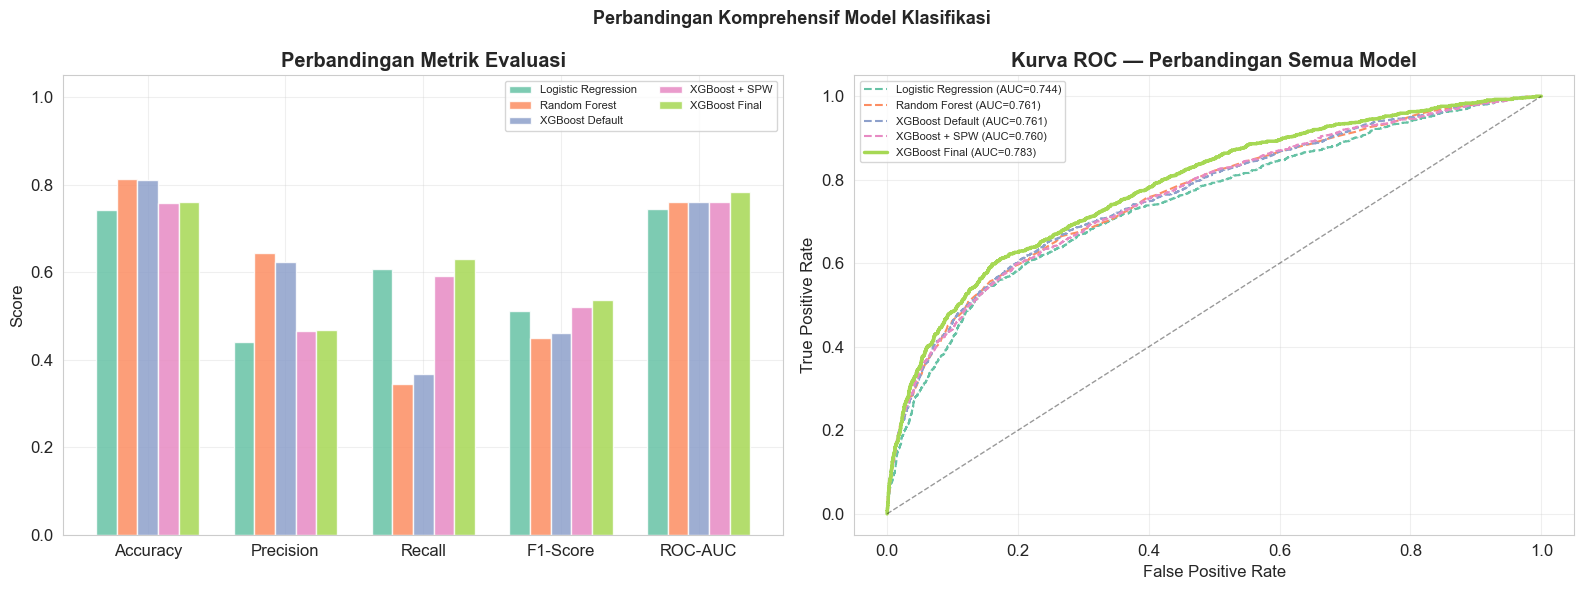

In [51]:
# ── Visualisasi Perbandingan ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

metrics_bar = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
model_names = list(models.keys())
palette_cmp = sns.color_palette('Set2', len(model_names))

x   = np.arange(len(metrics_bar))
w   = 0.15
for i, (mname, mcolor) in enumerate(zip(model_names, palette_cmp)):
    vals = [models[mname][m] for m in metrics_bar]
    bars = axes[0].bar(x + i * w, vals, w, label=mname,
                       color=mcolor, edgecolor='white', alpha=0.85)

axes[0].set_title('Perbandingan Metrik Evaluasi', fontweight='bold')
axes[0].set_xticks(x + w * (len(model_names) - 1) / 2)
axes[0].set_xticklabels(metrics_bar)
axes[0].set_ylim(0, 1.05)
axes[0].legend(fontsize=8, ncol=2)
axes[0].set_ylabel('Score')

# ROC Curves semua model
roc_data = [
    ('Logistic Regression', y_prob, palette_cmp[0])
    for y_prob, palette_cmp, name in [
        (lr_prob,          palette_cmp[0], 'LR'),
    ]
]

all_roc = [
    ('Logistic Regression', lr_prob,          palette_cmp[0]),
    ('Random Forest',        rf_prob,          palette_cmp[1]),
    ('XGBoost Default',      y_prob_default,   palette_cmp[2]),
    ('XGBoost + SPW',        y_prob_balanced,  palette_cmp[3]),
    ('XGBoost Final',        y_prob_final,     palette_cmp[4]),
]

for mname, probs, mcolor in all_roc:
    fpr_m, tpr_m, _ = roc_curve(y_test, probs)
    auc_m = roc_auc_score(y_test, probs)
    ls    = '-' if 'Final' in mname else '--'
    lw    = 2.5 if 'Final' in mname else 1.5
    axes[1].plot(fpr_m, tpr_m, color=mcolor, lw=lw, ls=ls,
                 label=f'{mname} (AUC={auc_m:.3f})')

axes[1].plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.4)
axes[1].set_title('Kurva ROC — Perbandingan Semua Model', fontweight='bold')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend(fontsize=8)

plt.suptitle('Perbandingan Komprehensif Model Klasifikasi',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 10. Analisis Kesalahan Prediksi

Analisis False Negative (default tidak terdeteksi):
  Jumlah FN                  : 492
  Rata-rata probabilitas FN  : 0.3428
  LIMIT_BAL rata-rata FN     : 171,972
  PAY_0 rata-rata FN         : -0.4329

Analisis False Positive (bukan default, tapi diprediksi default):
  Jumlah FP                  : 947
  Rata-rata probabilitas FP  : 0.6700


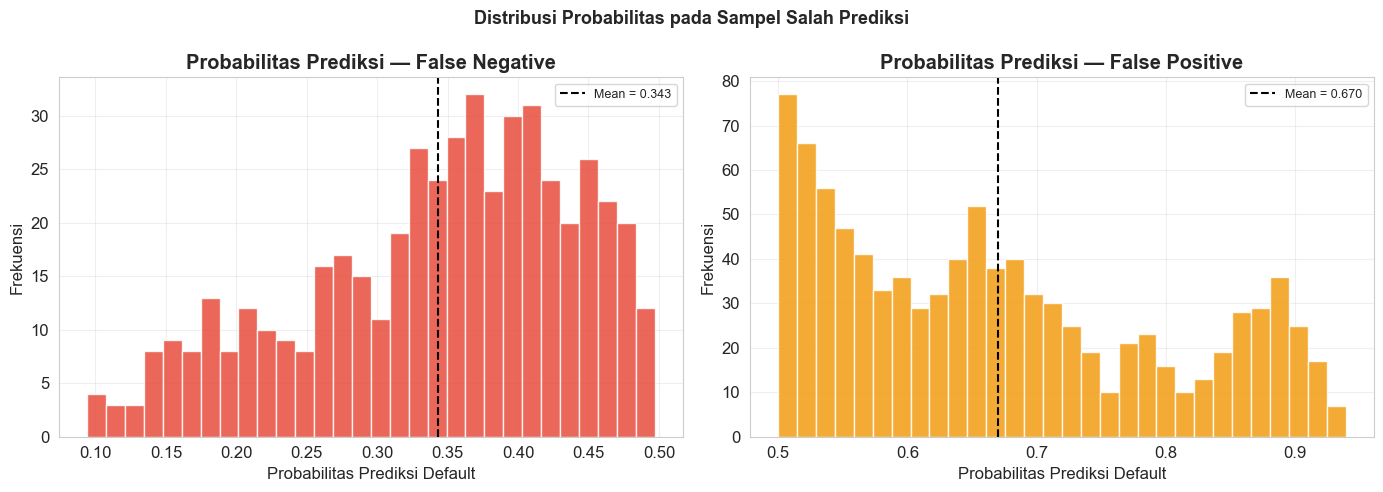

In [52]:
# Analisis False Negative (paling kritis): default yang tidak terdeteksi
df_test_result = X_test.copy()
df_test_result['y_true']   = y_test.values
df_test_result['y_pred']   = y_pred_final
df_test_result['y_prob']   = y_prob_final
df_test_result['error_type'] = np.select(
    [
        (df_test_result['y_true'] == 1) & (df_test_result['y_pred'] == 0),  # FN
        (df_test_result['y_true'] == 0) & (df_test_result['y_pred'] == 1),  # FP
        (df_test_result['y_true'] == df_test_result['y_pred'])               # Benar
    ],
    ['False Negative', 'False Positive', 'Benar'],
    default='Lainnya'
)

fn_df = df_test_result[df_test_result['error_type'] == 'False Negative']
fp_df = df_test_result[df_test_result['error_type'] == 'False Positive']

print('Analisis False Negative (default tidak terdeteksi):')
print(f'  Jumlah FN                  : {len(fn_df):,}')
print(f'  Rata-rata probabilitas FN  : {fn_df["y_prob"].mean():.4f}')
print(f'  LIMIT_BAL rata-rata FN     : {fn_df["LIMIT_BAL"].mean():,.0f}')
print(f'  PAY_0 rata-rata FN         : {fn_df["PAY_0"].mean():.4f}')

print('\nAnalisis False Positive (bukan default, tapi diprediksi default):')
print(f'  Jumlah FP                  : {len(fp_df):,}')
print(f'  Rata-rata probabilitas FP  : {fp_df["y_prob"].mean():.4f}')

# Distribusi probabilitas per jenis prediksi
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for group, color, ax, title in [
    ('False Negative', '#e74c3c', axes[0], 'Probabilitas Prediksi — False Negative'),
    ('False Positive', '#f39c12', axes[1], 'Probabilitas Prediksi — False Positive'),
]:
    subset = df_test_result[df_test_result['error_type'] == group]['y_prob']
    ax.hist(subset, bins=30, color=color, edgecolor='white', alpha=0.85)
    ax.axvline(subset.mean(), color='black', ls='--', lw=1.5,
               label=f'Mean = {subset.mean():.3f}')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Probabilitas Prediksi Default')
    ax.set_ylabel('Frekuensi')
    ax.legend(fontsize=9)

plt.suptitle('Distribusi Probabilitas pada Sampel Salah Prediksi',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 11. Export Hasil

In [53]:
df_result = X_test.copy()
df_result['default_actual']    = y_test.values
df_result['default_predicted'] = y_pred_final
df_result['prob_default']      = y_prob_final
df_result['prediction_status'] = np.where(
    df_result['default_actual'] == df_result['default_predicted'],
    np.where(df_result['default_actual'] == 1, 'True Positive', 'True Negative'),
    np.where(df_result['default_actual'] == 1, 'False Negative', 'False Positive')
)

out_path = 'classification_results_XGBoost_CreditCard.csv'
df_result.to_csv(out_path, index=False)

print(f'Hasil disimpan ke: {out_path}')
print(f'Jumlah baris   : {len(df_result):,}')
print(f'Jumlah kolom   : {len(df_result.columns)}')
print()
print('Distribusi prediction_status:')
for status, cnt in df_result['prediction_status'].value_counts().items():
    print(f'  {status:<20}: {cnt:5,} ({cnt/len(df_result)*100:.1f}%)')

df_result.head()

Hasil disimpan ke: classification_results_XGBoost_CreditCard.csv
Jumlah baris   : 6,000
Jumlah kolom   : 34

Distribusi prediction_status:
  True Negative       : 3,726 (62.1%)
  False Positive      :   947 (15.8%)
  True Positive       :   835 (13.9%)
  False Negative      :   492 (8.2%)


,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,PAY_MAX,LATE_COUNT,TOTAL_BILL,TOTAL_PAY,PAY_BILL_RATIO,UTIL_RATE,default_actual,default_predicted,prob_default,prediction_status
6907,50000.0,1,2,2,46,-1,-1,-1,-1,0,...,0,0,36334.0,36457.0,1.003385,0.030800,0,0,0.336755,True Negative
24575,150000.0,1,1,1,31,-1,-1,-2,-2,-2,...,-1,0,26694.0,41694.0,1.561924,0.100000,0,0,0.377810,True Negative
26766,50000.0,1,2,2,25,0,0,0,0,0,...,0,0,296559.0,11682.0,0.039392,0.961300,0,0,0.419347,True Negative
2156,290000.0,2,1,2,25,0,0,0,0,0,...,0,0,1627617.0,81677.0,0.050182,1.054562,1,0,0.285612,False Negative
3179,500000.0,2,2,1,27,-2,-2,-2,-2,-2,...,-2,0,64907.0,78874.0,1.215185,0.022708,0,0,0.109425,True Negative


---
## 12. Kesimpulan

### Ringkasan Pipeline Final

| Tahap | Detail |
|---|---|
| Algoritma | XGBoost (Extreme Gradient Boosting) |
| Dataset | UCI Credit Card (30.000 nasabah, 23 fitur asli) |
| Preprocessing | Cleaning nilai tidak valid + 7 fitur engineering baru |
| Imbalance Handling | `scale_pos_weight` = neg/pos ratio (3.52) |
| Split | Stratified 80/20 |
| Tuning | Grid search manual (CV 3-fold, F1-Score sebagai target) |
| Metrik Utama | F1-Score & ROC-AUC |

### Temuan Utama

**F1-Score sebagai metrik target, bukan Accuracy.**
Dataset imbalanced dengan sekitar 22% kelas positif. Mengoptimalkan Accuracy pada data ini dapat menghasilkan model yang hanya memprediksi "tidak default" untuk seluruh sampel dengan Accuracy 78%. F1-Score menyeimbangkan Precision dan Recall, di mana Recall lebih kritis secara bisnis karena melewatkan nasabah berisiko (False Negative) jauh lebih mahal dibandingkan false alarm (False Positive).

**Feature engineering berbasis domain meningkatkan performa secara signifikan.**
Fitur PAY_MAX, LATE_COUNT, dan PAY_AVG mendominasi feature importance (Gain) masing-masing sebesar 42.83%, 16.43%, dan 2.84%. Ketiga fitur ini merupakan hasil rekayasa dari kolom PAY_0 sampai PAY_6 yang mengkodekan pola keterlambatan secara agregat, lebih informatif dibandingkan nilai mentah per bulan.

**scale_pos_weight sebagai penanganan class imbalance.**
Dibandingkan model default tanpa penanganan imbalance (F1 = 0.4615), penambahan scale_pos_weight = 3.52 meningkatkan F1-Score menjadi 0.5204 dengan kenaikan Recall dari 0.3662 menjadi 0.5908. Pendekatan ini lebih efisien dibandingkan oversampling sintetis untuk dataset besar.

**Threshold klasifikasi adalah keputusan bisnis.**
Threshold default 0.5 bukan selalu optimal. Menurunkan threshold meningkatkan Recall (lebih banyak default terdeteksi) dengan konsekuensi Precision turun. Trade-off ini harus disesuaikan dengan biaya relatif antara False Negative dan False Positive dalam konteks operasional lembaga keuangan.

**XGBoost Final mencapai performa terbaik di antara semua model yang dibandingkan.**
F1-Score 0.5372 dan ROC-AUC 0.7829 melampaui Logistic Regression (F1 = 0.5103, AUC = 0.7445) dan Random Forest (F1 = 0.4487, AUC = 0.7615), menunjukkan bahwa kemampuan XGBoost menangkap interaksi non-linear antar fitur riwayat pembayaran memberikan keunggulan nyata pada dataset ini.